# Energy Consumption Forecasting: EDA & Data Processing

**Dataset**: UCI Appliances Energy Prediction
**Source**: Real smart home in Stambruges, Belgium — ZigBee wireless sensor network
**Goal**: Understand the data, then build the complete processing pipeline

**What this notebook covers:**

**Part 1 — Exploratory Data Analysis**
1. Data loading & basic inspection
2. Target variable analysis (Appliances energy)
3. Seasonality patterns (hourly, daily, weekly)
4. Correlation analysis
5. Sensor redundancy check
6. rv1/rv2 noise validation

**Part 2 — Data Processing Pipeline**
7. Hourly resampling with column-specific aggregation
8. Sensor consolidation (18 → 7 features)
9. Cyclical time features
10. Lag & rolling features
11. Train/Val/Test split
12. Feature scaling
13. Save processed outputs

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import warnings

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 30)

RAW_PATH = Path("../data/raw/energydata_complete.csv")
PROCESSED_DIR = Path("../data/processed")

---
# Part 1: Exploratory Data Analysis
## 1. Data Loading & Inspection

In [2]:
df = pd.read_csv(RAW_PATH, parse_dates=["date"], index_col="date")
print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min()} → {df.index.max()}")
print(f"Frequency: {pd.infer_freq(df.index)}")
print(f"\nDtypes:\n{df.dtypes}")
df.head()

Shape: (19735, 28)
Date range: 2016-01-11 17:00:00 → 2016-05-27 18:00:00
Frequency: 10min

Dtypes:
Appliances       int64
lights           int64
T1             float64
RH_1           float64
T2             float64
RH_2           float64
T3             float64
RH_3           float64
T4             float64
RH_4           float64
T5             float64
RH_5           float64
T6             float64
RH_6           float64
T7             float64
RH_7           float64
T8             float64
RH_8           float64
T9             float64
RH_9           float64
T_out          float64
Press_mm_hg    float64
RH_out         float64
Windspeed      float64
Visibility     float64
Tdewpoint      float64
rv1            float64
rv2            float64
dtype: object


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,55.20,7.026667,84.256667,17.200000,41.626667,18.2,48.900000,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,55.20,6.833333,84.063333,17.200000,41.560000,18.2,48.863333,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,55.09,6.560000,83.156667,17.200000,41.433333,18.2,48.730000,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,55.09,6.433333,83.423333,17.133333,41.290000,18.1,48.590000,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,55.09,6.366667,84.893333,17.200000,41.230000,18.1,48.590000,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [3]:
# Null and duplicate check
print("=== Null counts ===")
print(df.isnull().sum().sum(), "total nulls")

print("\n=== Duplicates ===")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate timestamps: {df.index.duplicated().sum()}")

print("\n=== Summary Statistics ===")
df.describe().T

=== Null counts ===
0 total nulls

=== Duplicates ===
Duplicate rows: 0
Duplicate timestamps: 0

=== Summary Statistics ===


,count,mean,std,min,25%,50%,75%,max
Appliances,19735.0,97.694958,102.524891,10.000000,50.000000,60.000000,100.000000,1080.000000
lights,19735.0,3.801875,7.935988,0.000000,0.000000,0.000000,0.000000,70.000000
T1,19735.0,21.686571,1.606066,16.790000,20.760000,21.600000,22.600000,26.260000
RH_1,19735.0,40.259739,3.979299,27.023333,37.333333,39.656667,43.066667,63.360000
T2,19735.0,20.341219,2.192974,16.100000,18.790000,20.000000,21.500000,29.856667
RH_2,19735.0,40.420420,4.069813,20.463333,37.900000,40.500000,43.260000,56.026667
T3,19735.0,22.267611,2.006111,17.200000,20.790000,22.100000,23.290000,29.236000
RH_3,19735.0,39.242500,3.254576,28.766667,36.900000,38.530000,41.760000,50.163333
T4,19735.0,20.855335,2.042884,15.100000,19.530000,20.666667,22.100000,26.200000
RH_4,19735.0,39.026904,4.341321,27.660000,35.530000,38.400000,42.156667,51.090000


**Findings:**
- 19,735 rows at 10-minute intervals (~4.5 months: Jan 11 → May 27, 2016)
- Zero nulls, zero duplicates — the dataset is clean
- 28 columns: 1 target, 1 lights, 9 temps, 9 humidity, 6 weather, 2 noise (rv1/rv2)

## 2. Target Variable Analysis (Appliances)

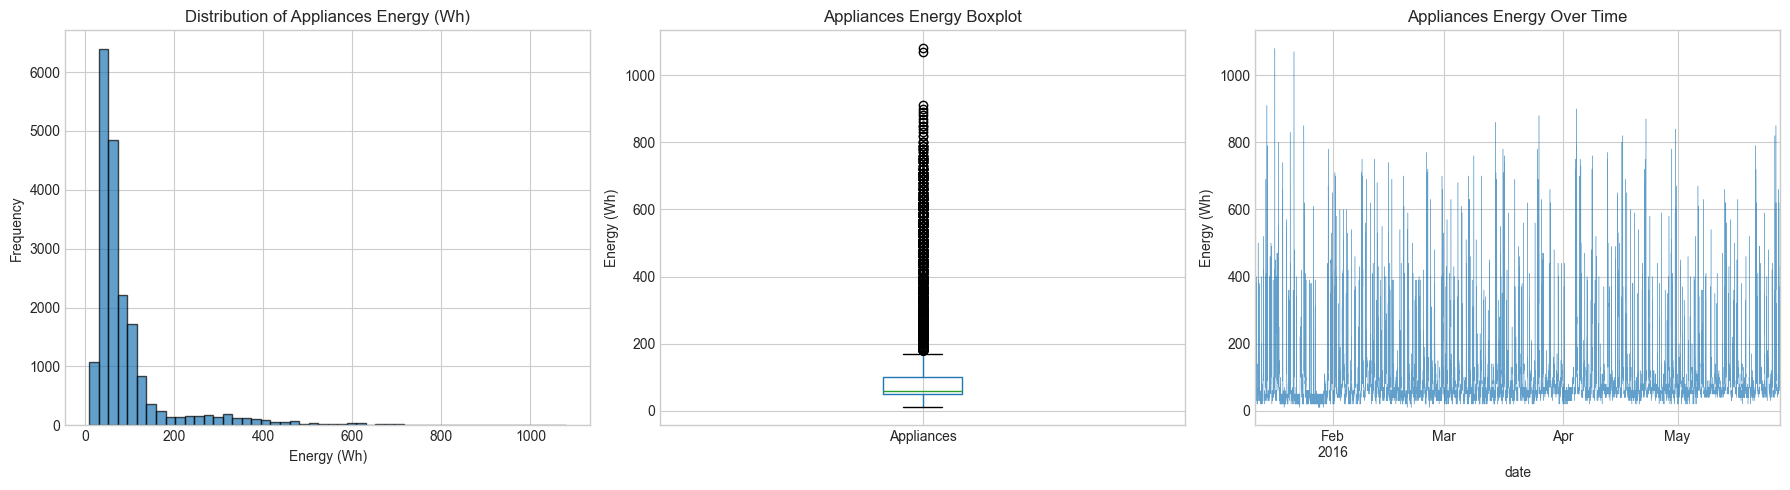

Skewness: 3.39
Mean: 97.7 Wh | Median: 60.0 Wh
95th percentile: 330.0 Wh
Max: 1080.0 Wh


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram with KDE
df["Appliances"].hist(bins=50, ax=axes[0], edgecolor="black", alpha=0.7)
axes[0].set_title("Distribution of Appliances Energy (Wh)")
axes[0].set_xlabel("Energy (Wh)")
axes[0].set_ylabel("Frequency")

# Boxplot
df[["Appliances"]].boxplot(ax=axes[1])
axes[1].set_title("Appliances Energy Boxplot")
axes[1].set_ylabel("Energy (Wh)")

# Time series
df["Appliances"].plot(ax=axes[2], linewidth=0.3, alpha=0.7)
axes[2].set_title("Appliances Energy Over Time")
axes[2].set_ylabel("Energy (Wh)")

plt.tight_layout()
plt.show()

print(f"Skewness: {df['Appliances'].skew():.2f}")
print(f"Mean: {df['Appliances'].mean():.1f} Wh | Median: {df['Appliances'].median():.1f} Wh")
print(f"95th percentile: {df['Appliances'].quantile(0.95):.1f} Wh")
print(f"Max: {df['Appliances'].max():.1f} Wh")

**Findings:**
- Heavy right skew — most 10-min readings are low (50-100 Wh), with occasional spikes up to 1080 Wh
- Median is much lower than mean, confirming the skew
- Many outliers visible in the boxplot — these are real consumption events (cooking, heating), not errors

## 3. Seasonality Analysis

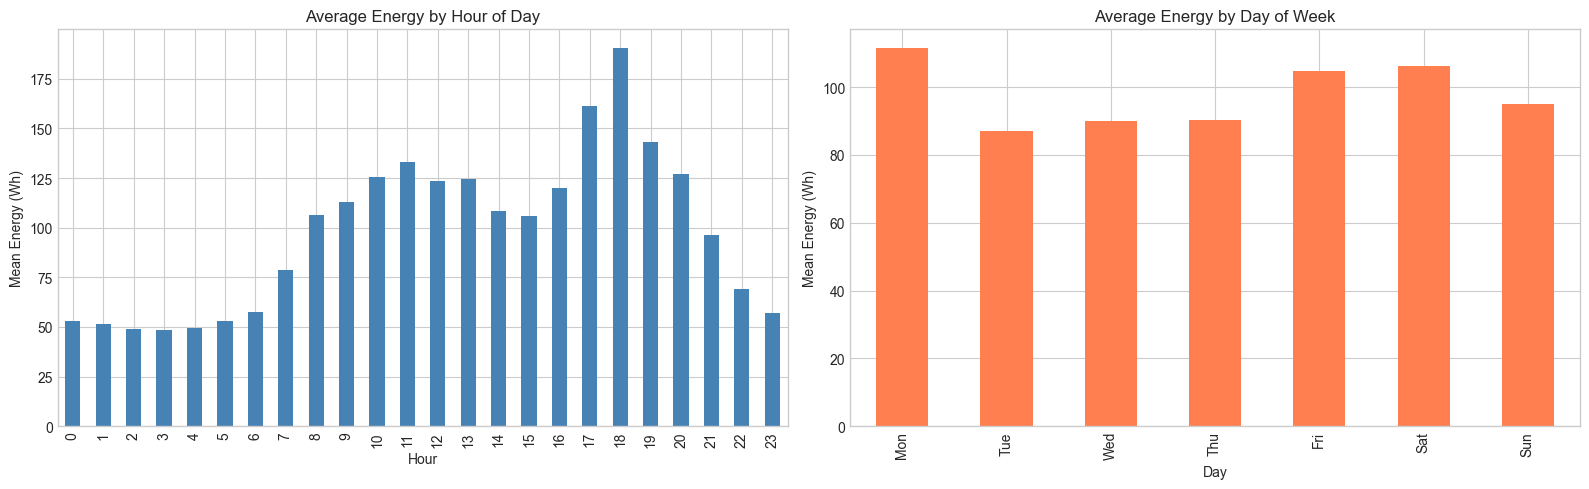

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Hourly pattern
df.groupby(df.index.hour)["Appliances"].mean().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Average Energy by Hour of Day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Mean Energy (Wh)")

# Daily pattern
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
daily = df.groupby(df.index.dayofweek)["Appliances"].mean()
daily.index = day_names
daily.plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("Average Energy by Day of Week")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Mean Energy (Wh)")

plt.tight_layout()
plt.show()

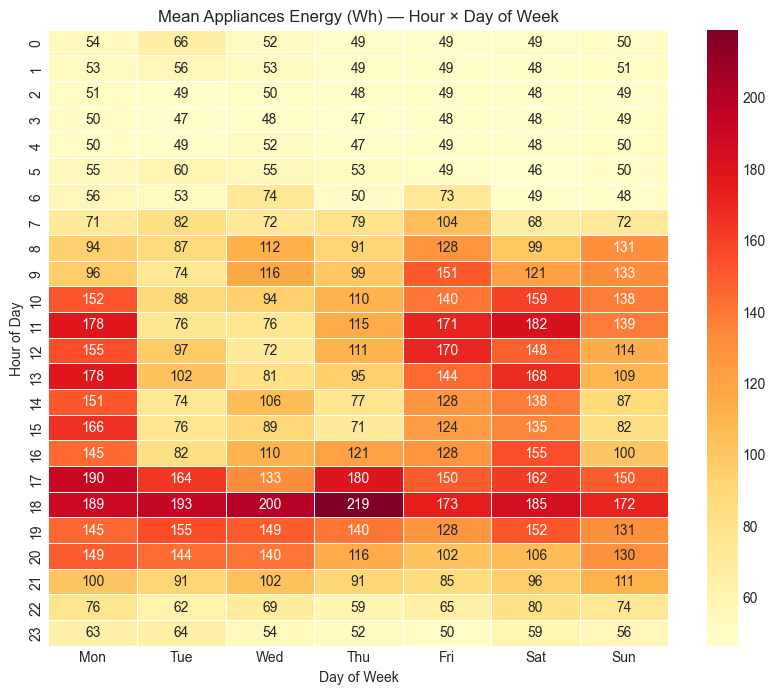

In [6]:
# Hour × Day of Week heatmap
pivot = df.pivot_table(values="Appliances", index=df.index.hour, columns=df.index.dayofweek, aggfunc="mean")
pivot.columns = day_names

plt.figure(figsize=(10, 8))
sns.heatmap(pivot, cmap="YlOrRd", annot=True, fmt=".0f", linewidths=0.5)
plt.title("Mean Appliances Energy (Wh) — Hour × Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Hour of Day")
plt.show()

**Findings:**
- Clear daily pattern: low at night (2-6am), peaks around morning (7-9am) and evening (17-19pm)
- Weekend energy tends to be higher during daytime (people home all day)
- The heatmap confirms the hour×day interaction — justifies using both hour and day_of_week as features

## 4. Correlation Analysis

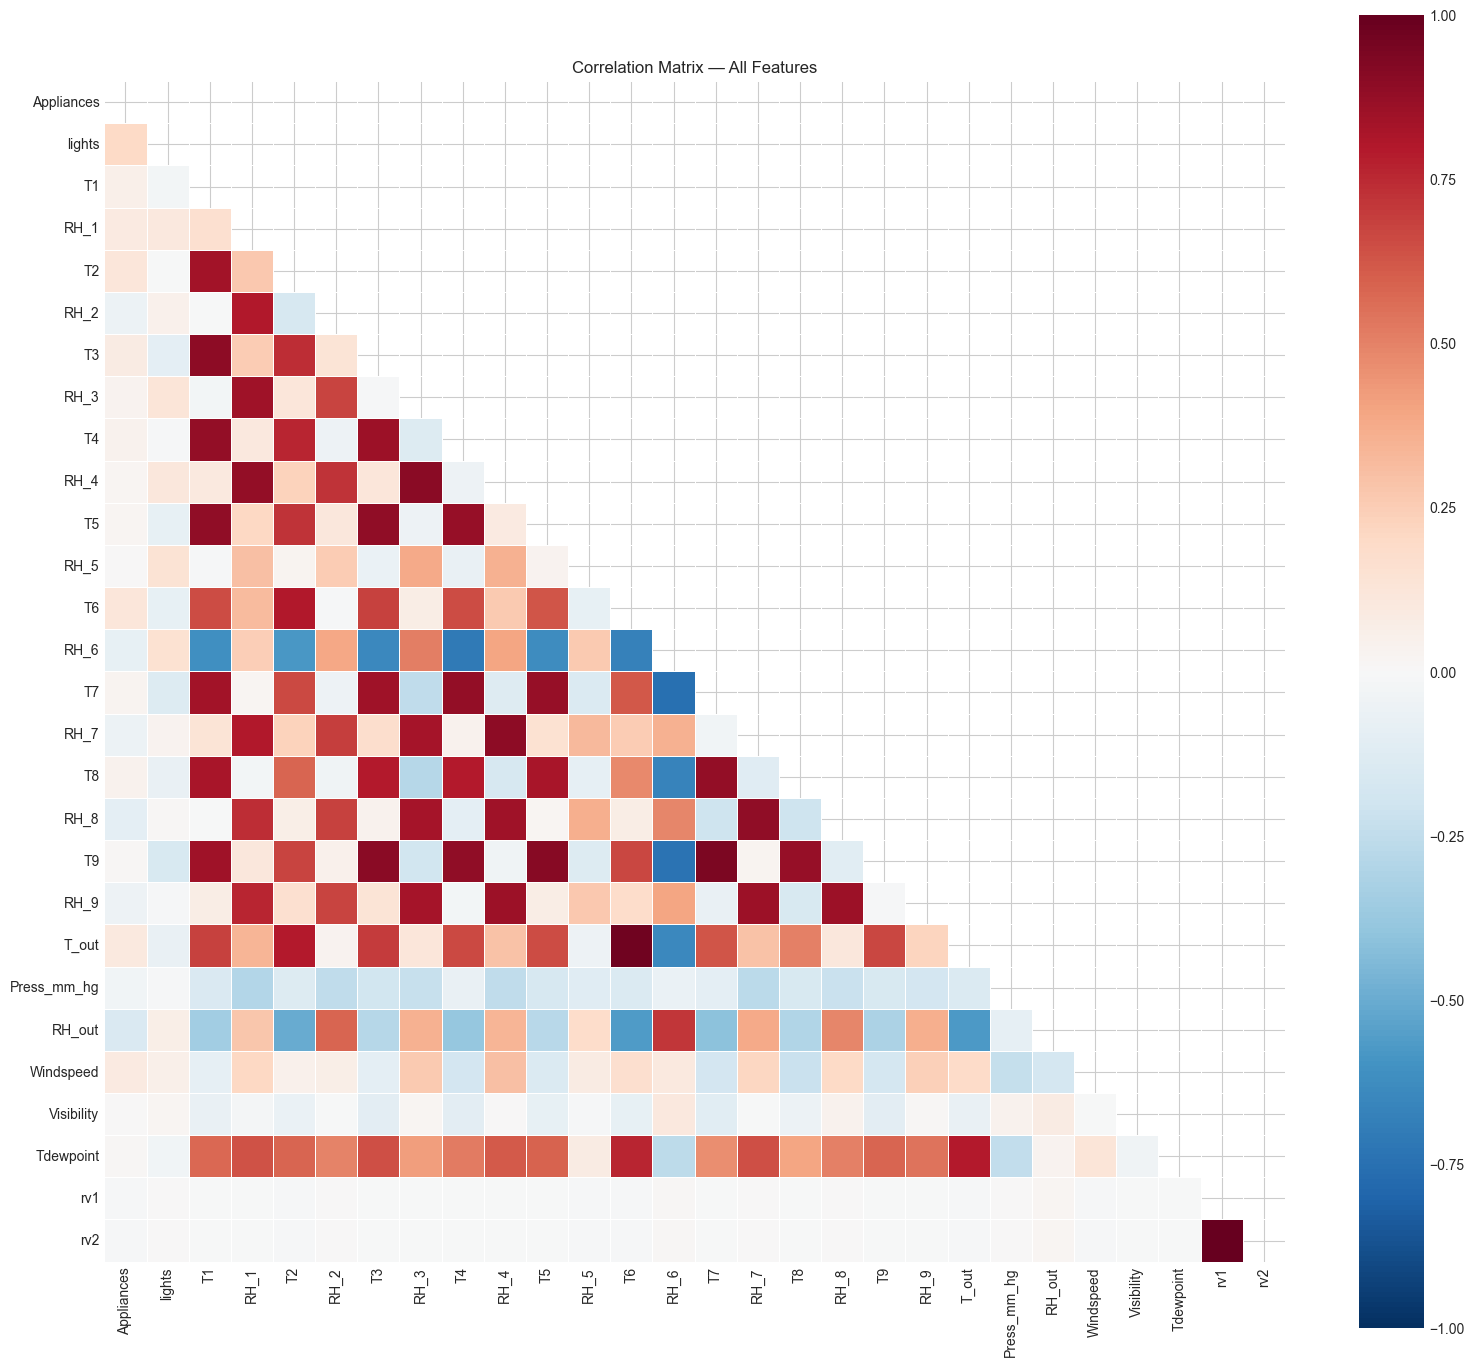

In [7]:
# Full correlation heatmap
plt.figure(figsize=(16, 14))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, square=True)
plt.title("Correlation Matrix — All Features")
plt.tight_layout()
plt.show()

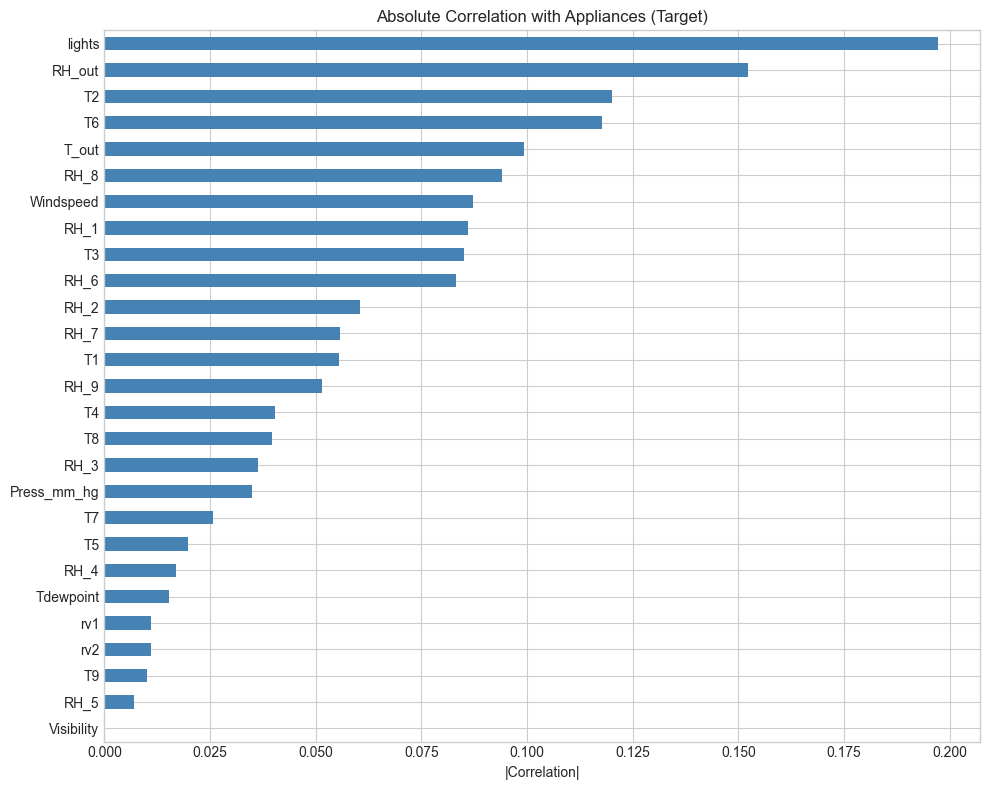

Top 10 correlations with Appliances:
lights       0.197278
RH_out       0.152282
T2           0.120073
T6           0.117638
T_out        0.099155
RH_8         0.094039
Windspeed    0.087122
RH_1         0.086031
T3           0.085060
RH_6         0.083178
dtype: float64


In [8]:
# Top correlations with target
target_corr = df.corrwith(df["Appliances"]).drop("Appliances").abs().sort_values(ascending=True)

plt.figure(figsize=(10, 8))
target_corr.plot(kind="barh", color="steelblue")
plt.title("Absolute Correlation with Appliances (Target)")
plt.xlabel("|Correlation|")
plt.tight_layout()
plt.show()

print("Top 10 correlations with Appliances:")
print(target_corr.sort_values(ascending=False).head(10))

## 5. Sensor Redundancy Check

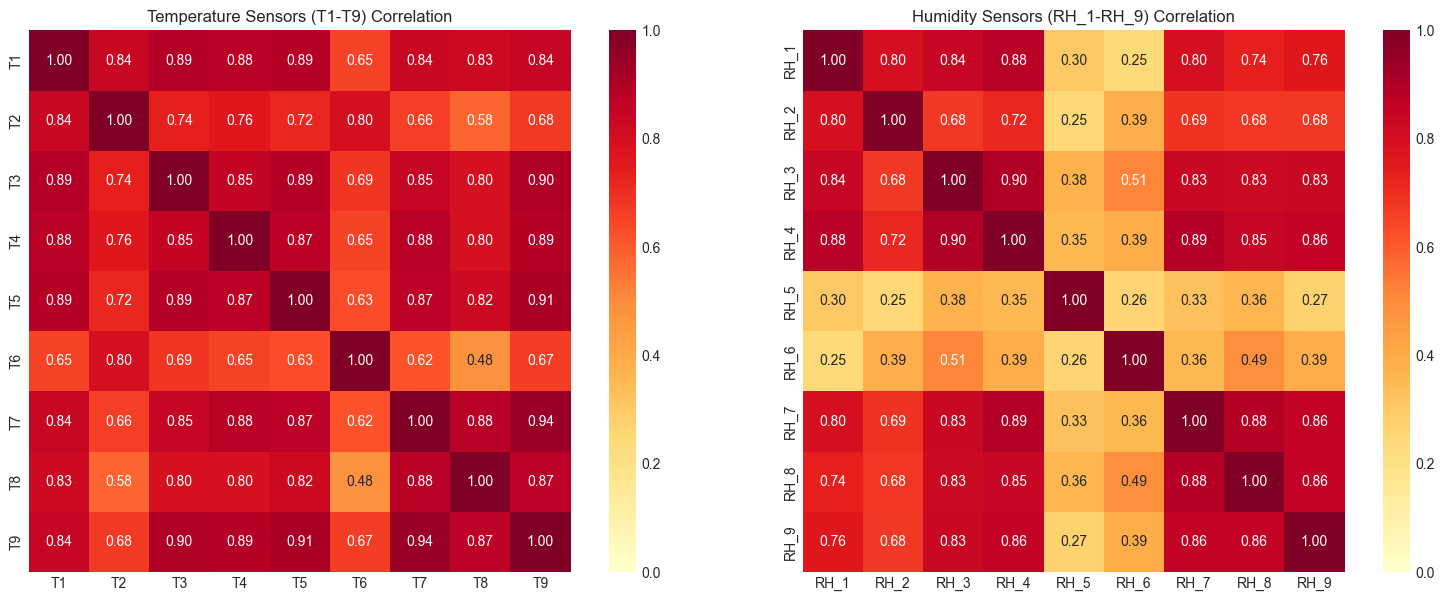

Temperature sensors — min pairwise correlation: 0.483
Humidity sensors — min pairwise correlation: 0.245


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Temperature sensors
temp_cols = [f"T{i}" for i in range(1, 10)]
sns.heatmap(df[temp_cols].corr(), annot=True, fmt=".2f", cmap="YlOrRd",
            ax=axes[0], vmin=0, vmax=1, square=True)
axes[0].set_title("Temperature Sensors (T1-T9) Correlation")

# Humidity sensors
hum_cols = [f"RH_{i}" for i in range(1, 10)]
sns.heatmap(df[hum_cols].corr(), annot=True, fmt=".2f", cmap="YlOrRd",
            ax=axes[1], vmin=0, vmax=1, square=True)
axes[1].set_title("Humidity Sensors (RH_1-RH_9) Correlation")

plt.tight_layout()
plt.show()

print("Temperature sensors — min pairwise correlation:", df[temp_cols].corr().min().min().round(3))
print("Humidity sensors — min pairwise correlation:", df[hum_cols].corr().min().min().round(3))

**Findings:**
- Temperature sensors are highly correlated with each other (most > 0.8) — rooms track together
- Humidity sensors show moderate to high correlation
- This confirms we can consolidate 18 sensor columns → 7 meaningful aggregates without losing much information

## 6. rv1/rv2 Noise Validation

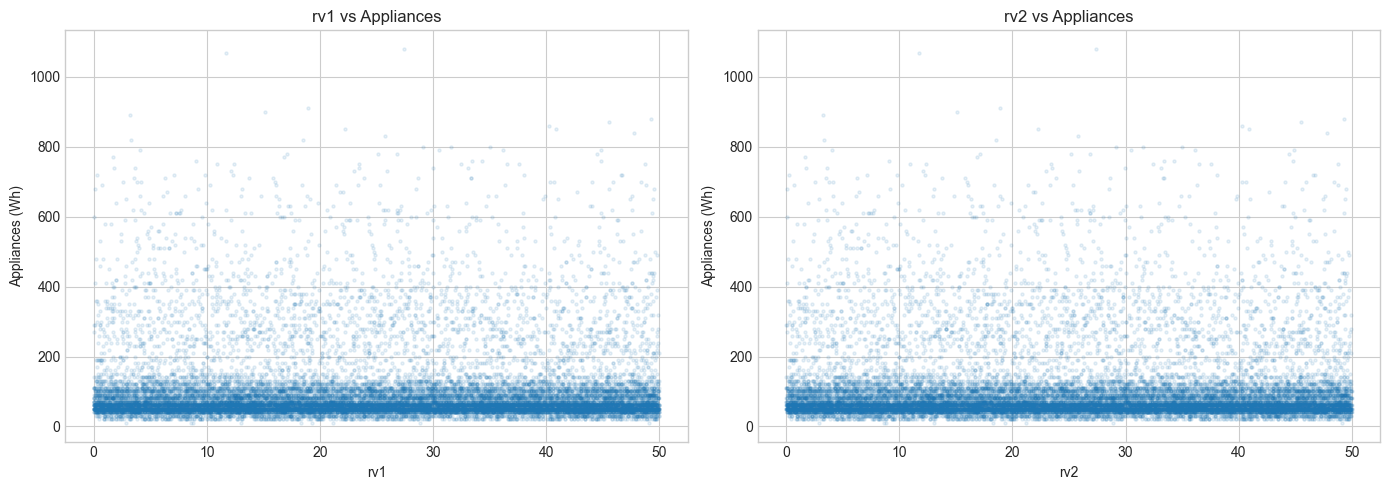

Correlation with Appliances:
  rv1: -0.0111
  rv2: -0.0111

rv1 stats: mean=25.0, std=14.5
rv2 stats: mean=25.0, std=14.5

Conclusion: rv1 and rv2 are random noise — will be DROPPED


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df["rv1"], df["Appliances"], alpha=0.1, s=5)
axes[0].set_title("rv1 vs Appliances")
axes[0].set_xlabel("rv1")
axes[0].set_ylabel("Appliances (Wh)")

axes[1].scatter(df["rv2"], df["Appliances"], alpha=0.1, s=5)
axes[1].set_title("rv2 vs Appliances")
axes[1].set_xlabel("rv2")
axes[1].set_ylabel("Appliances (Wh)")

plt.tight_layout()
plt.show()

print("Correlation with Appliances:")
print(f"  rv1: {df['rv1'].corr(df['Appliances']):.4f}")
print(f"  rv2: {df['rv2'].corr(df['Appliances']):.4f}")
print(f"\nrv1 stats: mean={df['rv1'].mean():.1f}, std={df['rv1'].std():.1f}")
print(f"rv2 stats: mean={df['rv2'].mean():.1f}, std={df['rv2'].std():.1f}")
print("\nConclusion: rv1 and rv2 are random noise — will be DROPPED")

## EDA Summary

| Finding | Implication |
|---|---|
| Target is heavily right-skewed | Model must handle spiky, non-normal energy data |
| Clear hourly & daily seasonality | Cyclical time features (sin/cos) will be valuable |
| Weekend vs weekday differences | `is_weekend` binary feature justified |
| Indoor sensors highly correlated | Consolidate 18 → 7 aggregate features |
| rv1/rv2 are pure noise | Drop them before processing |
| `lights` correlates with `Appliances` | Keep as feature but monitor for leakage |

---
# Part 2: Data Processing Pipeline

The processing logic lives in `src/data_processing.py` for reuse across the MLOps pipeline.
This section imports and validates each step.

In [11]:
# Import the data processing module
sys.path.insert(0, str(Path.cwd().parent / "src"))
import data_processing as dp

## 7. Load Raw Data

In [12]:
df_raw = dp.load_raw_data(RAW_PATH)
print(f"Shape: {df_raw.shape}")
print(f"Date range: {df_raw.index.min()} → {df_raw.index.max()}")
print(f"Columns: {df_raw.columns.tolist()}")
df_raw.head(3)

Shape: (19735, 28)
Date range: 2016-01-11 17:00:00 → 2016-05-27 18:00:00
Columns: ['Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'rv1', 'rv2']


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,55.20,7.026667,84.256667,17.2,41.626667,18.2,48.900000,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,55.20,6.833333,84.063333,17.2,41.560000,18.2,48.863333,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,55.09,6.560000,83.156667,17.2,41.433333,18.2,48.730000,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668


## 8. Resample to Hourly

Energy columns (Appliances, lights) → **SUM** (cumulative Wh).
All other columns → **MEAN** (instantaneous measures).

In [13]:
df_hourly = dp.resample_to_hourly(df_raw)
print(f"Before: {df_raw.shape[0]} rows (10-min) → After: {df_hourly.shape[0]} rows (hourly)")
print(f"Columns: {df_hourly.shape[1]} (rv1/rv2 dropped: {'rv1' not in df_hourly.columns})")
df_hourly.head(3)

Before: 19735 rows (10-min) → After: 3290 rows (hourly)
Columns: 26 (rv1/rv2 dropped: True)


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint
date,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-11 17:00:00,330,210,19.890000,46.502778,19.200000,44.626528,19.790000,44.897778,18.932778,45.738750,17.166667,55.116667,6.586667,84.260000,17.177778,41.400000,18.150000,48.710556,17.016667,45.446667,6.308333,733.750000,92.000000,6.166667,53.416667,5.050000
2016-01-11 18:00:00,1060,310,19.897778,45.879028,19.268889,44.438889,19.770000,44.863333,18.908333,46.066667,17.111111,54.977778,6.180000,87.204444,17.229583,42.046806,18.094444,48.597222,16.981667,45.290000,5.941667,734.266667,91.583333,5.416667,40.000000,4.658333
2016-01-11 19:00:00,1040,150,20.495556,52.805556,19.925556,46.061667,20.052222,47.227361,18.969444,47.815556,17.136111,55.869861,5.857361,88.131389,17.850000,45.017778,18.156111,49.213333,16.902222,45.311389,6.000000,734.791667,89.750000,6.000000,40.000000,4.391667


In [14]:
# Sanity check: manually verify one hour of resampling
test_hour = "2016-01-12 10:00:00"
hour_mask = (df_raw.index >= test_hour) & (df_raw.index < "2016-01-12 11:00:00")
raw_slice = df_raw.loc[hour_mask]

print(f"=== Manual check for hour starting {test_hour} ===")
print(f"Raw readings in this hour: {len(raw_slice)}")
print(f"Appliances SUM — manual: {raw_slice['Appliances'].sum():.1f}, pipeline: {df_hourly.loc[test_hour, 'Appliances']:.1f}")
print(f"T1 MEAN — manual: {raw_slice['T1'].mean():.4f}, pipeline: {df_hourly.loc[test_hour, 'T1']:.4f}")

=== Manual check for hour starting 2016-01-12 10:00:00 ===
Raw readings in this hour: 6
Appliances SUM — manual: 1380.0, pipeline: 1380.0
T1 MEAN — manual: 19.7833, pipeline: 19.7833


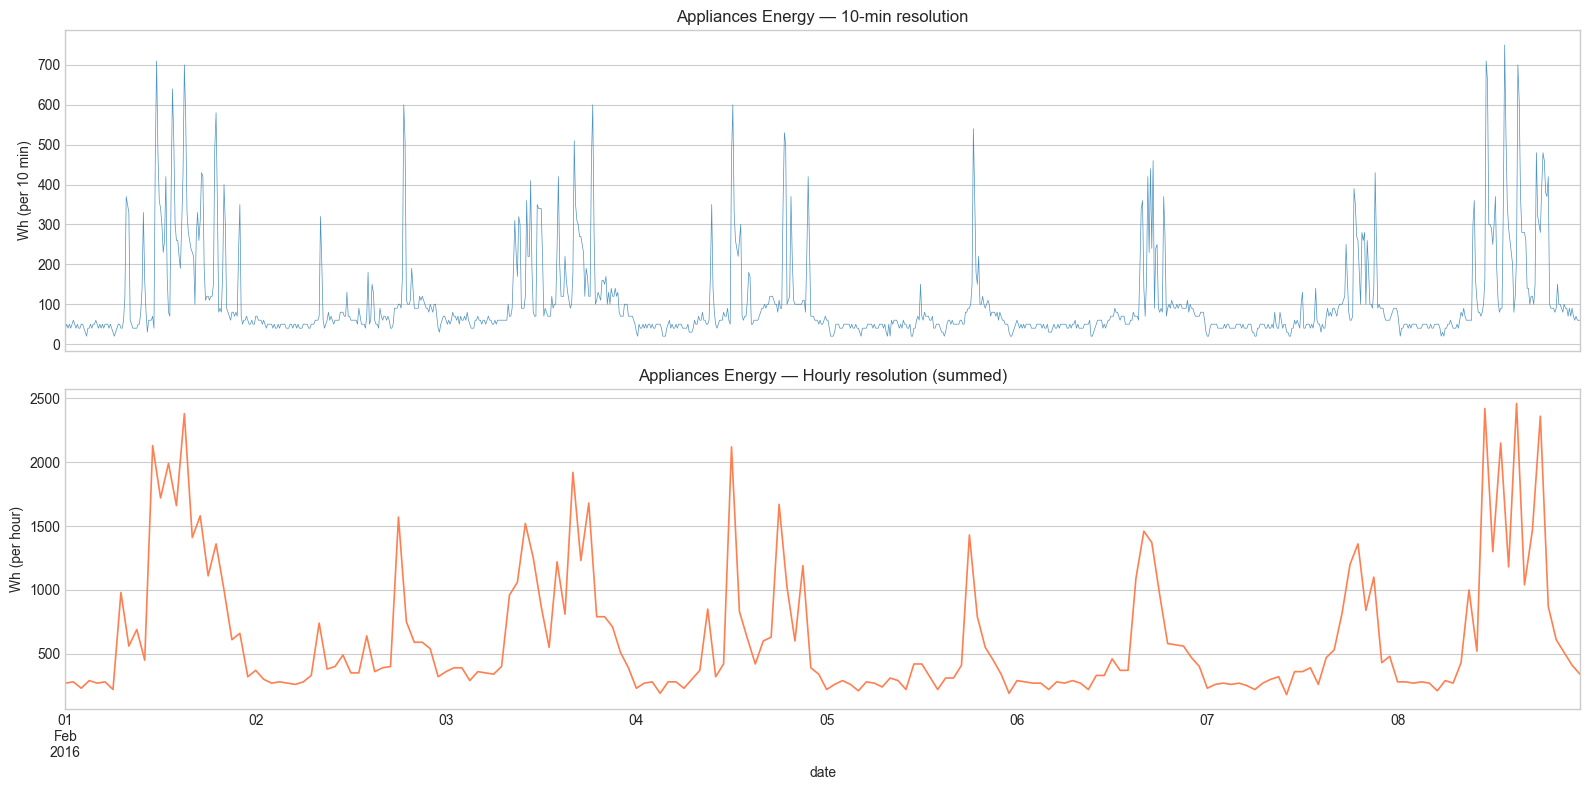

In [15]:
# Visual comparison: 1 week of 10-min vs hourly
week_start, week_end = "2016-02-01", "2016-02-08"

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

df_raw.loc[week_start:week_end, "Appliances"].plot(ax=axes[0], linewidth=0.5, alpha=0.8)
axes[0].set_title("Appliances Energy — 10-min resolution")
axes[0].set_ylabel("Wh (per 10 min)")

df_hourly.loc[week_start:week_end, "Appliances"].plot(ax=axes[1], linewidth=1.2, color="coral")
axes[1].set_title("Appliances Energy — Hourly resolution (summed)")
axes[1].set_ylabel("Wh (per hour)")

plt.tight_layout()
plt.show()

## 9. Sensor Consolidation

Reduce 9 temperature + 9 humidity sensors → 7 meaningful aggregate features:
- `T_indoor_mean`, `T_indoor_std`, `T_indoor_max`, `T_indoor_min`
- `RH_indoor_mean`, `RH_indoor_std`
- `T_diff` = indoor mean - outdoor temp (the #1 driver of heating/cooling energy)

In [16]:
df_consolidated = dp.consolidate_sensors(df_hourly)
print(f"Columns: {df_hourly.shape[1]} → {df_consolidated.shape[1]}")
print(f"\nNew features: {[c for c in df_consolidated.columns if c not in df_hourly.columns]}")
print(f"Dropped: T1-T9, RH_1-RH_9 ({18} individual sensor columns)")
df_consolidated.head(3)

Columns: 33 → 15

New features: []
Dropped: T1-T9, RH_1-RH_9 (18 individual sensor columns)


,Appliances,lights,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,T_indoor_mean,T_indoor_std,T_indoor_max,T_indoor_min,RH_indoor_mean,RH_indoor_std,T_diff
date,,,,,,,,,,,,,,,
2016-01-11 17:00:00,330,210,6.308333,733.750000,92.000000,6.166667,53.416667,5.050000,17.101173,4.099381,19.890000,6.586667,50.744414,13.117697,10.792840
2016-01-11 18:00:00,1060,310,5.941667,734.266667,91.583333,5.416667,40.000000,4.658333,17.049090,4.230448,19.897778,6.180000,51.040463,14.037343,11.107423
2016-01-11 19:00:00,1040,150,6.000000,734.791667,89.750000,6.000000,40.000000,4.391667,17.260509,4.466645,20.495556,5.857361,53.050432,13.638077,11.260509


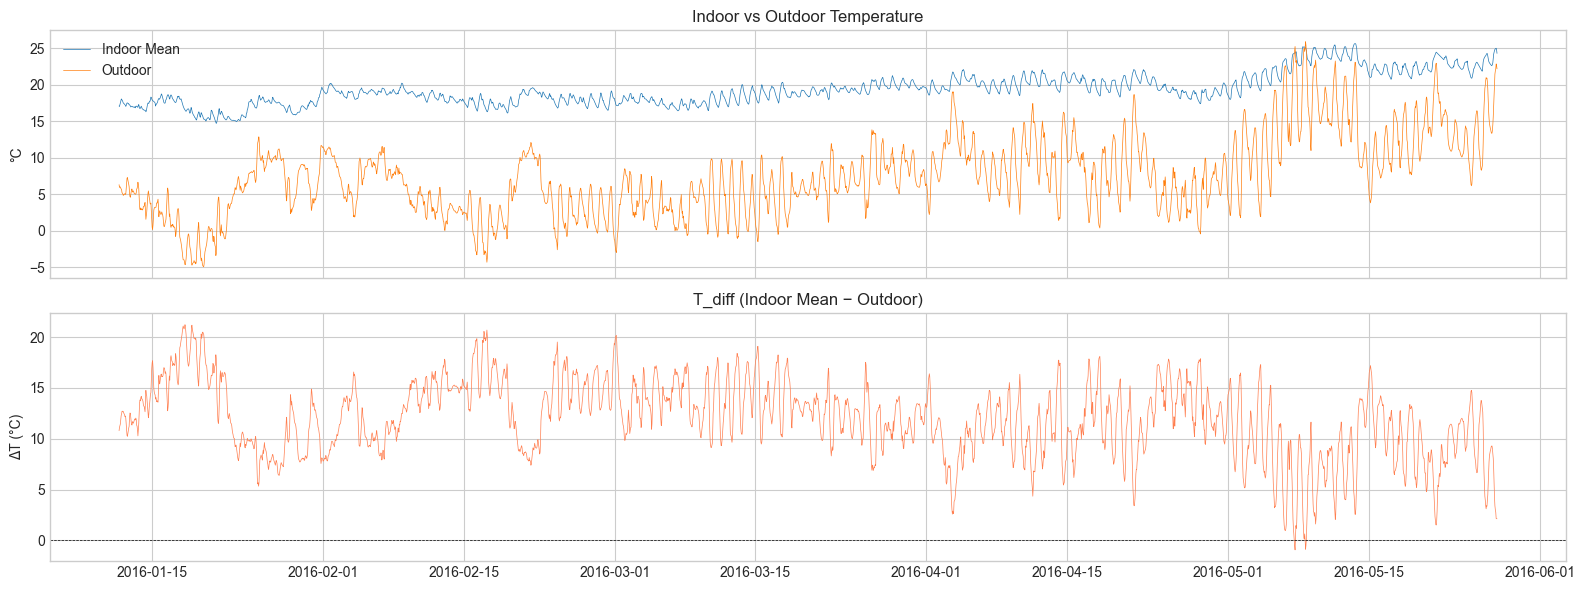

In [17]:
# Validate T_diff — the key engineered feature
fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

axes[0].plot(df_consolidated.index, df_consolidated["T_indoor_mean"], label="Indoor Mean", linewidth=0.5)
axes[0].plot(df_consolidated.index, df_consolidated["T_out"], label="Outdoor", linewidth=0.5)
axes[0].set_title("Indoor vs Outdoor Temperature")
axes[0].set_ylabel("°C")
axes[0].legend()

axes[1].plot(df_consolidated.index, df_consolidated["T_diff"], color="coral", linewidth=0.5)
axes[1].axhline(y=0, color="black", linestyle="--", linewidth=0.5)
axes[1].set_title("T_diff (Indoor Mean − Outdoor)")
axes[1].set_ylabel("ΔT (°C)")

plt.tight_layout()
plt.show()

## 10. Time Features

Cyclical sin/cos encoding preserves periodicity (hour 23 is close to hour 0).

In [18]:
df_time = dp.add_time_features(df_consolidated)
new_time_cols = [c for c in df_time.columns if c not in df_consolidated.columns]
print(f"New time features: {new_time_cols}")
df_time[new_time_cols].head(10)

New time features: []


""
date
2016-01-11 17:00:00
2016-01-11 18:00:00
2016-01-11 19:00:00
2016-01-11 20:00:00
2016-01-11 21:00:00
2016-01-11 22:00:00
2016-01-11 23:00:00
2016-01-12 00:00:00
2016-01-12 01:00:00


## Cyclical Encoding of Time Features

### The Problem with Raw Time Numbers

Time features like hour (0–23), day-of-week (0–6), and month (1–12) are **cyclic** — hour 23 is just 1 step away from hour 0, not 23 steps. If we feed raw integers to a model, it sees hour 0 and hour 23 as far apart, which is wrong.

| Feature | Raw range | Actual distance 23→0 |
|---------|-----------|----------------------|
| Hour | 0–23 | 1 hour apart |
| Day-of-week | 0–6 | 1 day apart |
| Month | 1–12 | 1 month apart |

---

### The Fix: Sin/Cos Encoding

We map each cyclic feature onto a **unit circle** using sine and cosine:

$$\text{sin} = \sin\!\left(\frac{2\pi \cdot x}{T}\right), \quad \text{cos} = \cos\!\left(\frac{2\pi \cdot x}{T}\right)$$

where `x` is the raw value and `T` is the period (24 for hours, 7 for days, 12 for months).

```python
df["hour_sin"] = np.sin(2 * np.pi * hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * hour / 24)
```

**Why two components (sin AND cos)?**  
Sin alone is ambiguous — `sin(hour=6)` equals `sin(hour=18)` (both = 1.0 or -1.0). Adding cosine removes the ambiguity: each hour maps to a **unique (sin, cos) coordinate** on the circle.

| Hour | sin | cos | Unique? |
|------|-----|-----|---------|
| 6 | 1.0 | 0.0 | ✓ |
| 18 | -1.0 | 0.0 | ✓ |

**Expected result:** plotting `hour_sin` vs `hour_cos` should form a perfect circle — confirming the encoding wraps correctly with no gaps or distortions.

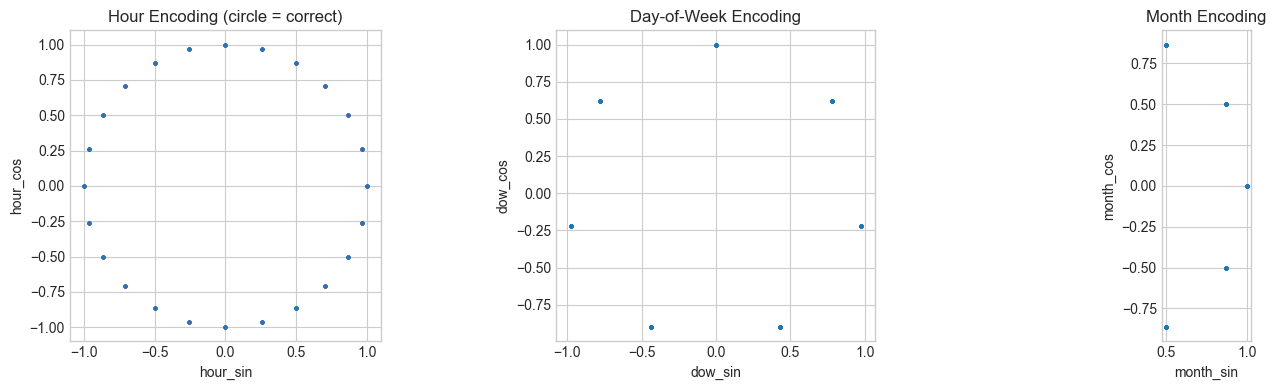

In [19]:
# Validate cyclical encoding: sin vs cos should form a circle
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(df_time["hour_sin"], df_time["hour_cos"], s=2, alpha=0.3)
axes[0].set_title("Hour Encoding (circle = correct)")
axes[0].set_xlabel("hour_sin")
axes[0].set_ylabel("hour_cos")
axes[0].set_aspect("equal")

axes[1].scatter(df_time["dow_sin"], df_time["dow_cos"], s=2, alpha=0.3)
axes[1].set_title("Day-of-Week Encoding")
axes[1].set_xlabel("dow_sin")
axes[1].set_ylabel("dow_cos")
axes[1].set_aspect("equal")

axes[2].scatter(df_time["month_sin"], df_time["month_cos"], s=2, alpha=0.3)
axes[2].set_title("Month Encoding")
axes[2].set_xlabel("month_sin")
axes[2].set_ylabel("month_cos")
axes[2].set_aspect("equal")

plt.tight_layout()
plt.show()

## Lag & Rolling Features

### Why Lag Features?

A model trained only on the current hour's sensor readings has no memory. In reality, energy consumption right now is strongly influenced by what happened **recently** — a house that was actively consuming energy 1 hour ago is likely still doing so.

**Lag features** give the model that memory by explicitly providing past values as input columns:

| Feature | What it captures |
|---------|-----------------|
| `Appliances_lag_1h` | Consumption 1 hour ago (`shift(1)`) |
| `Appliances_lag_24h` | Same hour yesterday (`shift(24)`) — captures daily routine |
| `T_diff_lag_1h` | Indoor-outdoor temperature gap 1 hour ago |

---

### Why Rolling Features?

A single past value is noisy. **Rolling (window) averages** smooth short-term spikes and expose medium-term trends:

| Feature | What it captures |
|---------|-----------------|
| `Appliances_rolling_6h_mean` | Average over the last 6 hours — short-term trend |
| `Appliances_rolling_24h_mean` | Average over the last 24 hours — daily baseline |


---

### The Leakage Problem — Why `shift(1)` Comes First

```python
# WRONG — leaks current value into the rolling window
df["rolling_6h"] = df["Appliances"].rolling(6).mean()

# CORRECT — window only sees strictly past values
df["rolling_6h"] = df["Appliances"].shift(1).rolling(6).mean()
```

Without `shift(1)`, `rolling(6).mean()` at time `t` includes the value at time `t` itself (the current row). This is **target leakage**: the model would be partially given the answer it needs to predict. At inference time, the current value doesn't exist yet, so the model would fail in production.

`shift(1)` pushes all values forward by one step first, ensuring the rolling window at time `t` only sees rows `t-1` through `t-6`.

---

### NaN Rows and Why They Are Dropped

Shifting introduces NaN at the start of the series:

- `shift(1)` → 1 NaN row
- `shift(24)` → 24 NaN rows  
- `shift(1).rolling(24)` → 25 NaN rows

The worst case is 25 rows (~1 day). These are dropped via `dropna()` — a negligible loss from ~3,289 hourly rows.

In [29]:
df_features = dp.add_lag_features(df_time)

lag_cols = [c for c in df_features.columns if c not in df_time.columns]
print(f"New lag/rolling features: {lag_cols}")
print(f"Rows before: {df_time.shape[0]} → after NaN drop: {df_features.shape[0]} (lost {df_time.shape[0] - df_features.shape[0]} rows)")
print(f"NaN count: {df_features.isnull().sum().sum()}")

New lag/rolling features: []
Rows before: 3290 → after NaN drop: 3266 (lost 24 rows)
NaN count: 0


In [30]:
# Validate lag correctness
sample_idx = 50  # pick an arbitrary row
row = df_features.iloc[sample_idx]
prev_row = df_features.iloc[sample_idx - 1]
row_24h_ago = df_features.iloc[sample_idx - 24]

print(f"Row timestamp: {df_features.index[sample_idx]}")
print(f"Appliances_lag_1h: {row['Appliances_lag_1h']:.1f} == prev Appliances: {prev_row['Appliances']:.1f} ✓" if abs(row['Appliances_lag_1h'] - prev_row['Appliances']) < 0.01 else "MISMATCH!")
print(f"Appliances_lag_24h: {row['Appliances_lag_24h']:.1f} == 24h-ago Appliances: {row_24h_ago['Appliances']:.1f} ✓" if abs(row['Appliances_lag_24h'] - row_24h_ago['Appliances']) < 0.01 else "MISMATCH!")

Row timestamp: 2016-01-14 19:00:00
Appliances_lag_1h: 1300.0 == prev Appliances: 1300.0 ✓
Appliances_lag_24h: 1280.0 == 24h-ago Appliances: 1280.0 ✓


In [31]:
# Final processed data overview
print(f"Final shape: {df_features.shape} ({df_features.shape[1] - 1} features + 1 target)")
print(f"\nAll columns:")
for i, col in enumerate(df_features.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\n{df_features.describe().T}")

Final shape: (3266, 27) (26 features + 1 target)

All columns:
   1. Appliances
   2. lights
   3. T_out
   4. Press_mm_hg
   5. RH_out
   6. Windspeed
   7. Visibility
   8. Tdewpoint
   9. T_indoor_mean
  10. T_indoor_std
  11. T_indoor_max
  12. T_indoor_min
  13. RH_indoor_mean
  14. RH_indoor_std
  15. T_diff
  16. hour_sin
  17. hour_cos
  18. dow_sin
  19. dow_cos
  20. is_weekend
  21. month_sin
  22. month_cos
  23. Appliances_lag_1h
  24. Appliances_lag_24h
  25. Appliances_rolling_6h_mean
  26. Appliances_rolling_24h_mean
  27. T_diff_lag_1h

                              count        mean         std         min  \
Appliances                   3266.0  585.737906  486.575454  170.000000   
lights                       3266.0   22.480098   40.719077    0.000000   
T_out                        3266.0    7.427478    5.333089   -4.961111   
Press_mm_hg                  3266.0  755.639600    7.292132  729.383333   
RH_out                       3266.0   79.682792   14.860514   25.

In [32]:
df_features.head(2)

,Appliances,lights,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,T_indoor_mean,T_indoor_std,T_indoor_max,T_indoor_min,RH_indoor_mean,RH_indoor_std,T_diff,hour_sin,hour_cos,dow_sin,dow_cos,is_weekend,month_sin,month_cos,Appliances_lag_1h,Appliances_lag_24h,Appliances_rolling_6h_mean,Appliances_rolling_24h_mean,T_diff_lag_1h
date,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-12 17:00:00,1310,120,6.041667,744.408333,79.166667,7.000000,33.583333,2.633333,17.266833,4.346072,20.022222,5.976111,47.813795,12.227008,11.225166,-0.965926,-2.588190e-01,0.781831,0.62349,0,0.5,0.866025,240.0,330.0,606.666667,624.583333,11.044813
2016-01-12 18:00:00,350,100,5.150000,744.825000,87.500000,6.583333,40.000000,3.225000,17.267284,4.725060,20.152778,5.014444,48.957762,14.214767,12.117284,-1.000000,-1.836970e-16,0.781831,0.62349,0,0.5,0.866025,1310.0,1060.0,770.000000,665.416667,11.225166


## 12. Train / Validation / Test Split

Chronological 70/15/15 split — no shuffling (time-series data must not leak future into training).

In [33]:
train, val, test = dp.split_data(df_features)

print(f"Train: {train.shape}  ({train.index.min().date()} → {train.index.max().date()})")
print(f"Val:   {val.shape}  ({val.index.min().date()} → {val.index.max().date()})")
print(f"Test:  {test.shape}  ({test.index.min().date()} → {test.index.max().date()})")

# Confirm no overlap
assert train.index.max() < val.index.min(), "Train/Val overlap!"
assert val.index.max() < test.index.min(), "Val/Test overlap!"
print("\nNo overlap between splits ✓")

Train: (2286, 27)  (2016-01-12 → 2016-04-16)
Val:   (490, 27)  (2016-04-16 → 2016-05-07)
Test:  (490, 27)  (2016-05-07 → 2016-05-27)

No overlap between splits ✓


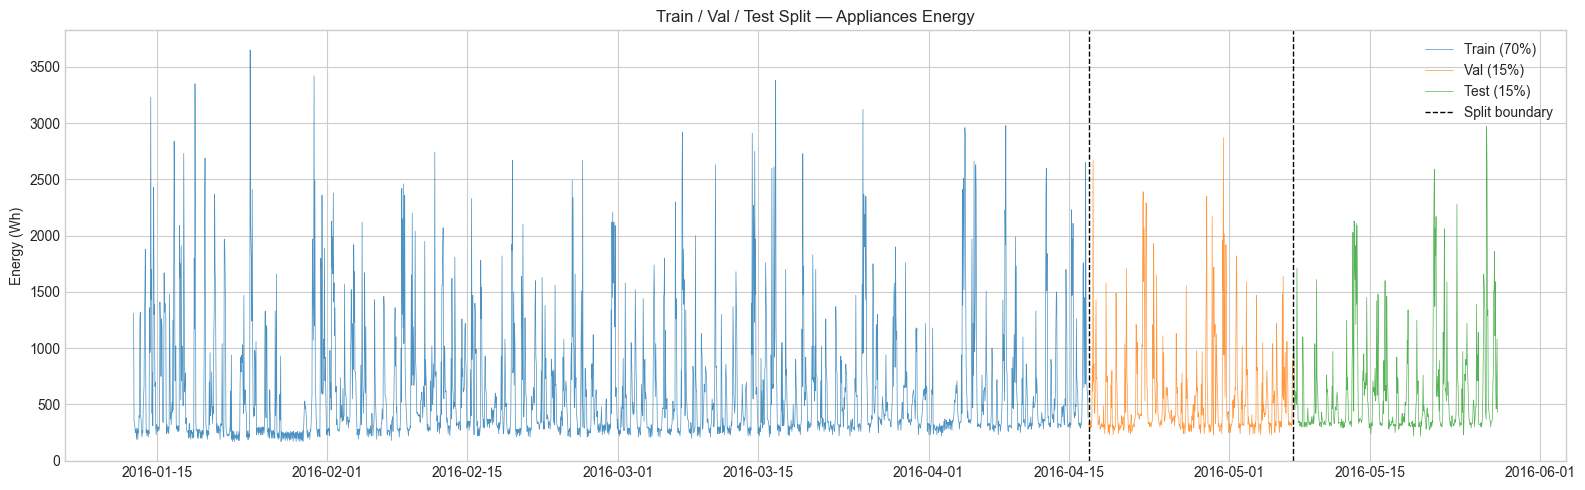

In [34]:
# Visualize split boundaries
plt.figure(figsize=(16, 5))

plt.plot(train.index, train["Appliances"], label="Train (70%)", linewidth=0.5, alpha=0.8)
plt.plot(val.index, val["Appliances"], label="Val (15%)", linewidth=0.5, alpha=0.8)
plt.plot(test.index, test["Appliances"], label="Test (15%)", linewidth=0.5, alpha=0.8)

plt.axvline(x=val.index.min(), color="black", linestyle="--", linewidth=1, label="Split boundary")
plt.axvline(x=test.index.min(), color="black", linestyle="--", linewidth=1)

plt.title("Train / Val / Test Split — Appliances Energy")
plt.ylabel("Energy (Wh)")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Feature Scaling

StandardScaler fitted on training data only — prevents data leakage.
Target (`Appliances`) is NOT scaled to keep metrics in interpretable Wh units.

In [35]:
scaled_train, scaled_val, scaled_test, scaler = dp.scale_data(train, val, test)

feature_cols = [c for c in scaled_train.columns if c != "Appliances"]

print("=== Scaling Validation ===")
print(f"Train feature mean (should be ~0): {scaled_train[feature_cols].mean().mean():.6f}")
print(f"Train feature std  (should be ~1): {scaled_train[feature_cols].std().mean():.6f}")
print(f"\nVal feature mean (should be close but NOT exactly 0): {scaled_val[feature_cols].mean().mean():.4f}")
print(f"Test feature mean (should be close but NOT exactly 0): {scaled_test[feature_cols].mean().mean():.4f}")
print(f"\nTarget NOT scaled: {(scaled_train['Appliances'] == train['Appliances']).all()} ✓")

=== Scaling Validation ===
Train feature mean (should be ~0): 0.000000
Train feature std  (should be ~1): 1.000219

Val feature mean (should be close but NOT exactly 0): -0.1407
Test feature mean (should be close but NOT exactly 0): 0.0109

Target NOT scaled: True ✓


## 14. Save Processed Outputs

In [36]:
import pickle

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Save full processed features (before split)
df_features.to_parquet(PROCESSED_DIR / "energy_hourly_features.parquet")

# Save scaled splits
scaled_train.to_parquet(PROCESSED_DIR / "train.parquet")
scaled_val.to_parquet(PROCESSED_DIR / "val.parquet")
scaled_test.to_parquet(PROCESSED_DIR / "test.parquet")

# Save scaler
with open(PROCESSED_DIR / "scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Saved to data/processed/:")
for p in sorted(PROCESSED_DIR.iterdir()):
    print(f"  {p.name}: {p.stat().st_size / 1024:.1f} KB")

Saved to data/processed/:
  energy_hourly_features.parquet: 353.2 KB
  scaler.pkl: 1.5 KB
  test.parquet: 82.6 KB
  train.parquet: 291.2 KB
  val.parquet: 82.3 KB


## 15. Validate Full Pipeline (`run_pipeline`)

Run the complete pipeline end-to-end as a final sanity check.

In [37]:
result = dp.run_pipeline(str(RAW_PATH), str(PROCESSED_DIR))

Pipeline complete!
  raw_rows: 19735
  hourly_rows_after_processing: 3266
  features: 27
  train_shape: (2286, 27)
  val_shape: (490, 27)
  test_shape: (490, 27)
  train_range: 2016-01-12 17:00:00 to 2016-04-16 22:00:00
  val_range: 2016-04-16 23:00:00 to 2016-05-07 08:00:00
  test_range: 2016-05-07 09:00:00 to 2016-05-27 18:00:00


---
## Summary

### Processing Pipeline
| Step | Rows | Columns | Description |
|---|---|---|---|
| Raw data | 19,735 | 28 | 10-min intervals, all sensors |
| Drop rv1/rv2 + resample hourly | ~3,289 | 26 | SUM energy, MEAN everything else |
| Consolidate sensors | ~3,289 | 15 | 18 sensors → 7 aggregates |
| Add time features | ~3,289 | 22 | Cyclical sin/cos + is_weekend |
| Add lag/rolling features | ~3,265 | 27 | Lag 1h/24h, rolling 6h/24h means |
| Final | ~3,265 | **27 features + 1 target** | Ready for modeling |

### Final Feature Set
| Category | Features | Count |
|---|---|---|
| Target | `Appliances` (hourly sum, Wh) | 1 |
| Indoor consolidated | `T_indoor_mean/std/max/min`, `RH_indoor_mean/std`, `T_diff` | 7 |
| Weather | `T_out`, `RH_out`, `Press_mm_hg`, `Windspeed`, `Visibility`, `Tdewpoint` | 6 |
| Time | `hour_sin/cos`, `dow_sin/cos`, `is_weekend`, `month_sin/cos` | 7 |
| Lag/rolling | `Appliances_lag_1h/24h`, `rolling_6h/24h_mean`, `T_diff_lag_1h` | 5 |
| Lights | `lights` (hourly sum) | 1 |

### Outputs saved to `data/processed/`
- `energy_hourly_features.parquet` — full processed dataset
- `train.parquet`, `val.parquet`, `test.parquet` — scaled splits
- `scaler.pkl` — fitted StandardScaler

### Next steps
- **Day 3-4**: Model training (LSTM/GRU baseline) with MLflow experiment tracking